## VGG16: Interpreting the model
### Loading python modules

In [13]:
from keras.utils import image_dataset_from_directory,custom_object_scope
from tensorflow.keras.applications.vgg16 import VGG16, preprocess_input
import tensorflow as tf
from tensorflow.keras.models import Model,load_model
from tensorflow.keras.layers import Input
from tensorflow.keras.layers import Conv2D
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import GlobalAveragePooling2D
from tensorflow.keras.layers import Dropout
from tensorflow.keras.layers import Rescaling,Resizing
from tensorflow.keras.callbacks import EarlyStopping,ReduceLROnPlateau
from sklearn.metrics import classification_report,confusion_matrix,accuracy_score
from collections import Counter
import random
import shap
import pickle
import pandas as pd
from tf_keras_vis import gradcam
from tf_keras_vis.utils.scores import CategoricalScore
from tf_keras_vis.utils.model_modifiers import ReplaceToLinear

import numpy as np
import matplotlib.pyplot as plt
import prettypyplot as pplt
import seaborn as sns

import cv2
import os
import shutil
from PIL import Image

### Loading datasets

In [ ]:
train_ds=image_dataset_from_directory('../../train_oversampling',seed=42,batch_size=16,image_size=(363,360))
class_names=train_ds.class_names
val_ds=image_dataset_from_directory('../../val',seed=42,batch_size=16,image_size=(363,360),label_mode='int')
test_ds=image_dataset_from_directory('../test_resize',seed=42,batch_size=16,image_size=(299,299),label_mode='int')
class_names=test_ds.class_names
class_names=['BAS','EOS','EBO','IG','LYT','MON','NGS','PLA']

Found 4814 files belonging to 8 classes.


### Preprocessing the datasets

In [ ]:
train_ds_pre=train_ds.map(lambda x,y:(preprocess_input(x),y))
val_ds_pre=val_ds.map(lambda x,y:(preprocess_input(x),y))
test_ds_pre=test_ds.map(lambda x,y:(preprocess_input(x),y))

### Loading the model

In [4]:
model=load_model('vgg16_model.h5')
with open('training_history_vgg.pkl', 'rb') as f:
    data=pickle.load(f)

### plot the loss and accuracy curves

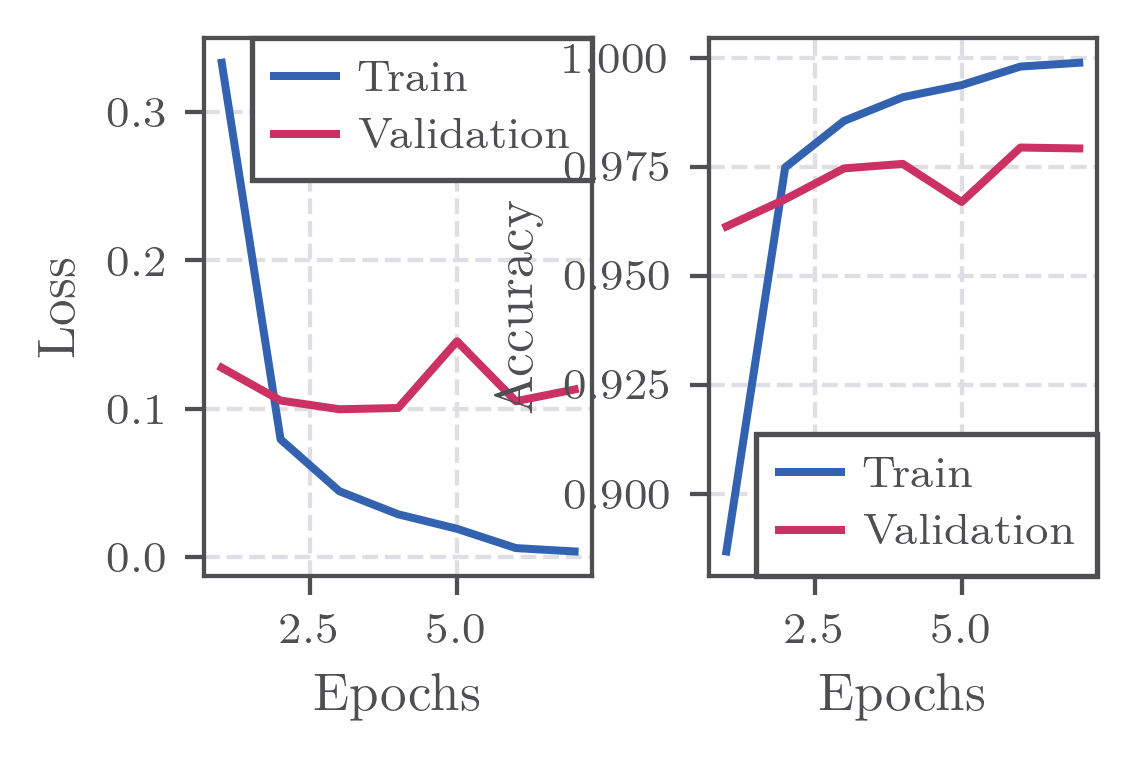

In [5]:
pplt.use_style()
train_loss=data['loss']
validation_loss=data['val_loss']
train_acc=data['accuracy']
validation_acc=data['val_accuracy']
fig,ax=plt.subplots(1,2,figsize=(3,2),gridspec_kw={'wspace':0.3})
ax[0].plot(np.arange(len(train_loss))+1,train_loss,label='Train')
ax[0].plot(np.arange(len(validation_loss))+1,validation_loss,label='Validation')
ax[0].set_xlabel('Epochs')
ax[0].set_ylabel('Loss')
ax[0].legend();
ax[1].plot(np.arange(len(train_acc))+1,train_acc,label='Train')
ax[1].plot(np.arange(len(validation_acc))+1,validation_acc,label='Validation')
ax[1].set_xlabel('Epochs')
ax[1].set_ylabel('Accuracy')
ax[1].legend()
pplt.savefig('loss_acc.png',dpi=300);

### Evaluate the model on the test dataset

In [6]:
def get_predictions_and_labels(dataset):
    true_labels = []
    pred_labels = []

    for images, labels in dataset:

        preds = model.predict(images, verbose=0)  
        pred_labels.extend(np.argmax(preds, axis=-1))  

        true_labels.extend(labels.numpy()) 

    return np.array(true_labels), np.array(pred_labels)

y_true, y_pred = get_predictions_and_labels(test_ds_pre)

In [10]:
print(accuracy_score(y_true, y_pred))
print(classification_report(y_true, y_pred, target_names=class_names))

0.9607395097631907
              precision    recall  f1-score   support

         BAS       0.94      0.95      0.95       195
         EOS       0.99      0.98      0.98       532
         EBO       0.95      0.96      0.95       245
          IG       0.95      0.87      0.91       459
         LYT       0.98      0.94      0.96       774
         MON       0.93      0.93      0.93       483
         NGS       0.95      0.99      0.97      1773
         PLA       0.99      0.99      0.99       353

    accuracy                           0.96      4814
   macro avg       0.96      0.95      0.96      4814
weighted avg       0.96      0.96      0.96      4814



### calculate and plot the confusion matrix

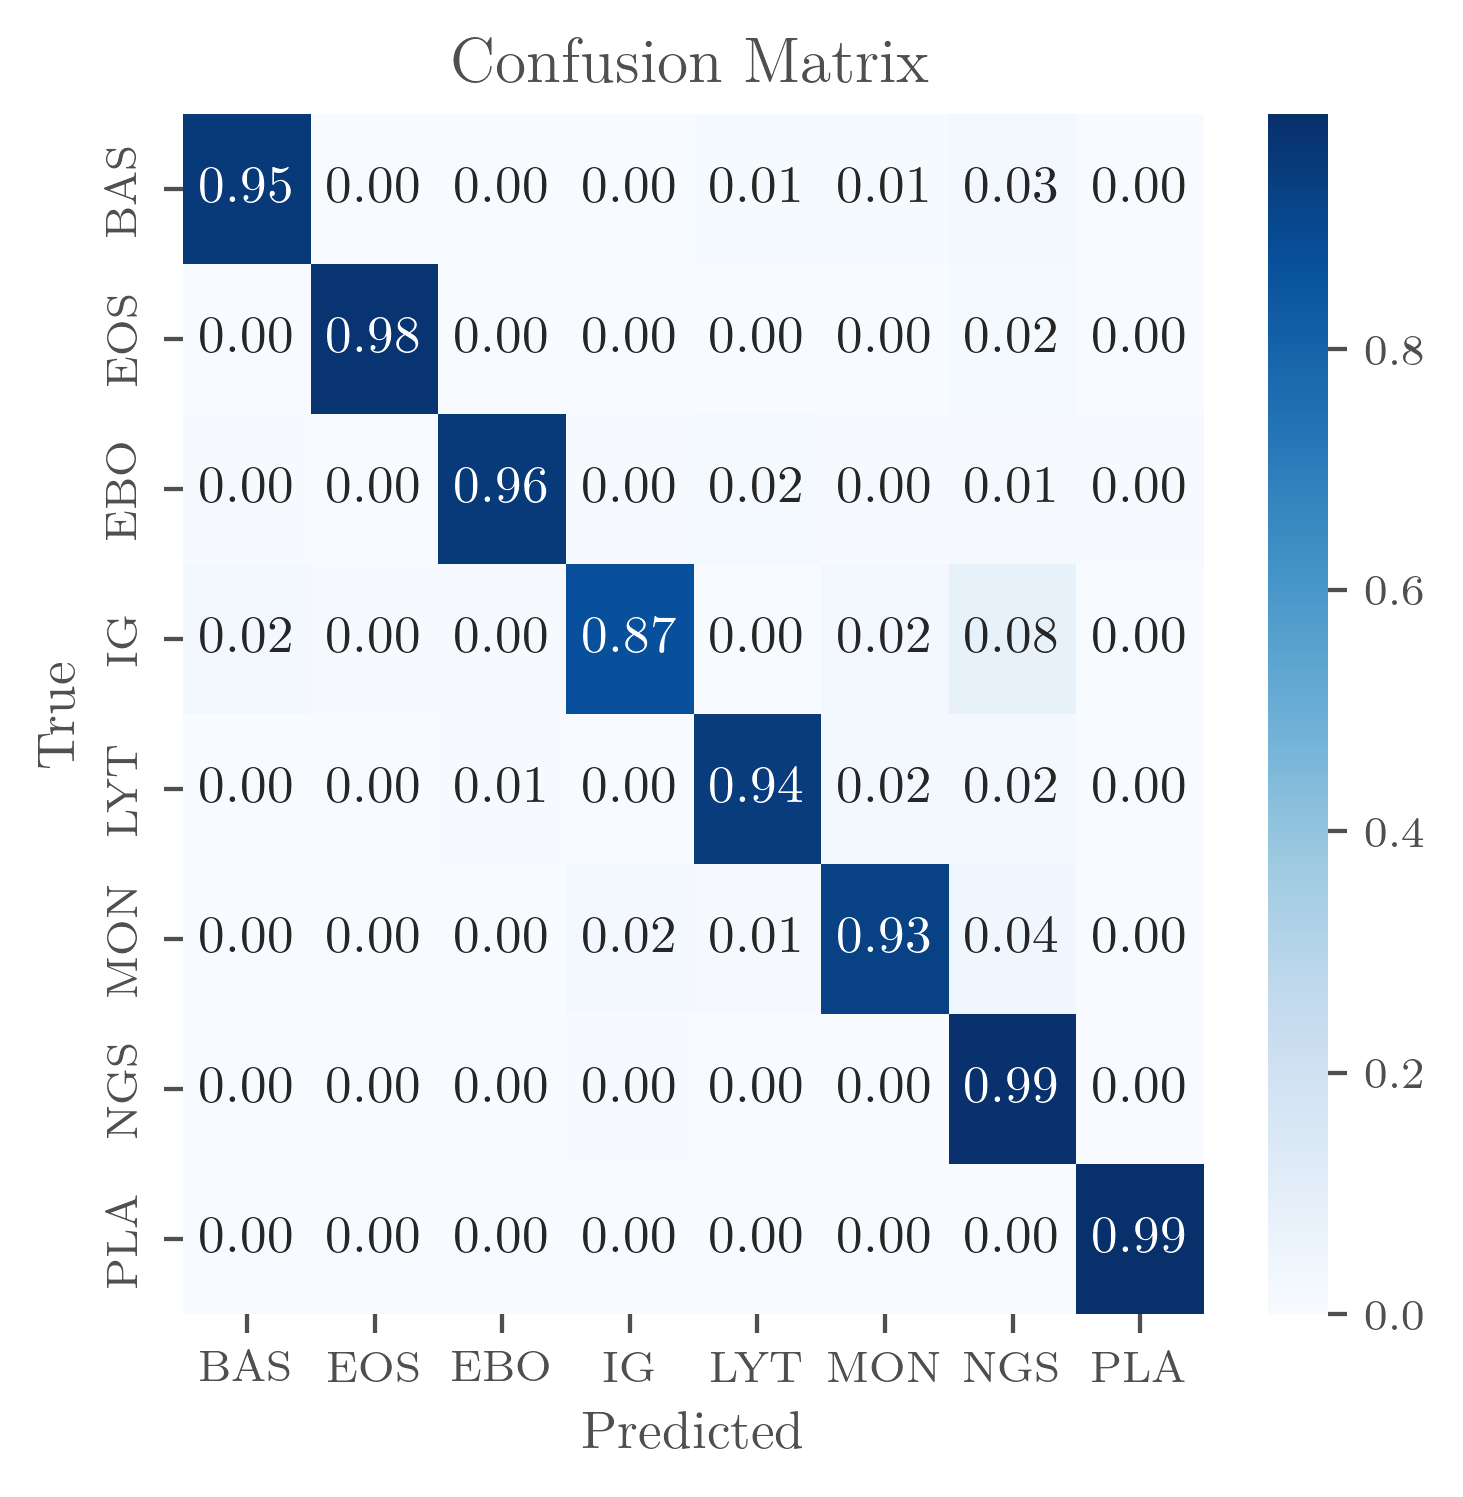

In [11]:
pplt.use_style()
cm = confusion_matrix(y_true, y_pred,normalize='true')
plt.figure(figsize=(4,4))
sns.heatmap(cm, annot=True, xticklabels=class_names, yticklabels=class_names, fmt='.2f', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('True')
#plt.xticks(rotation=45)
plt.title('Confusion Matrix')
pplt.savefig('cm.png',dpi=300)
plt.show()

### Define a function to get only the edges of a certain image

In [15]:
def get_canny_edge(img, threshold1=30, threshold2=80):
    """
    Function to get the canny edge of an image
    Input: img in (H, W, 3), dtype uint8 or float [0,1]
    Output: edge map (H, W, 3), float in [0,1]
    """
    # If float [0,1], convert to uint8
    if img.dtype != np.uint8:
        img = (img * 255).astype(np.uint8)

    # Gray scale
    gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

    # Gaussian blur
    gray = cv2.GaussianBlur(gray, (5, 5), 0)

    # Get the edge (invert edges so white = edge)
    edge = 255 - cv2.Canny(gray, threshold1, threshold2)

    # Convert to 3-channel float [0,1]
    edge = np.stack([edge]*3, axis=-1) / 255.0
    return edge


### Define the Grad-CAM function to interpret the model

In [16]:
def make_gradcam_heatmap(img_array, model, last_conv_layer_name='block5_conv3', pred_index=None):
    # build a model that maps inputs -> (last_conv_output, model_output)
    last_conv_layer = model.get_layer(last_conv_layer_name)
    grad_model = tf.keras.models.Model(model.inputs, [last_conv_layer.output, model.output])

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_array)
        if pred_index is None:
            pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    # gradients of the target class w.r.t. conv feature maps
    grads = tape.gradient(class_channel, conv_outputs)  # shape: (1, H, W, C)

    # global average pooling on gradients -> importance for each feature map channel
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))

    conv_outputs = conv_outputs[0]  # remove batch dim
    heatmap = tf.reduce_sum(tf.multiply(pooled_grads, conv_outputs), axis=-1)
    #heatmap = tf.reduce_sum(conv_outputs * pooled_grads[tf.newaxis, tf.newaxis, :], axis=-1)

    # post-process
    heatmap = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()

### Plot 4 random images with their Grad-CAM results

<>:47: SyntaxWarning: invalid escape sequence '\%'
<>:47: SyntaxWarning: invalid escape sequence '\%'
C:\Users\ahmed\AppData\Local\Temp\ipykernel_9620\1363848393.py:47: SyntaxWarning: invalid escape sequence '\%'
  f"T: {class_names[true_label]} \n P: {class_names[pred_class]} ({pred_prob*100:.2f}\%)",
C:\Users\ahmed\AppData\Roaming\Python\Python312\site-packages\keras\src\models\functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: ['input_layer']
Received: inputs=Tensor(shape=(1, 299, 299, 3))
  warnings.warn(msg)


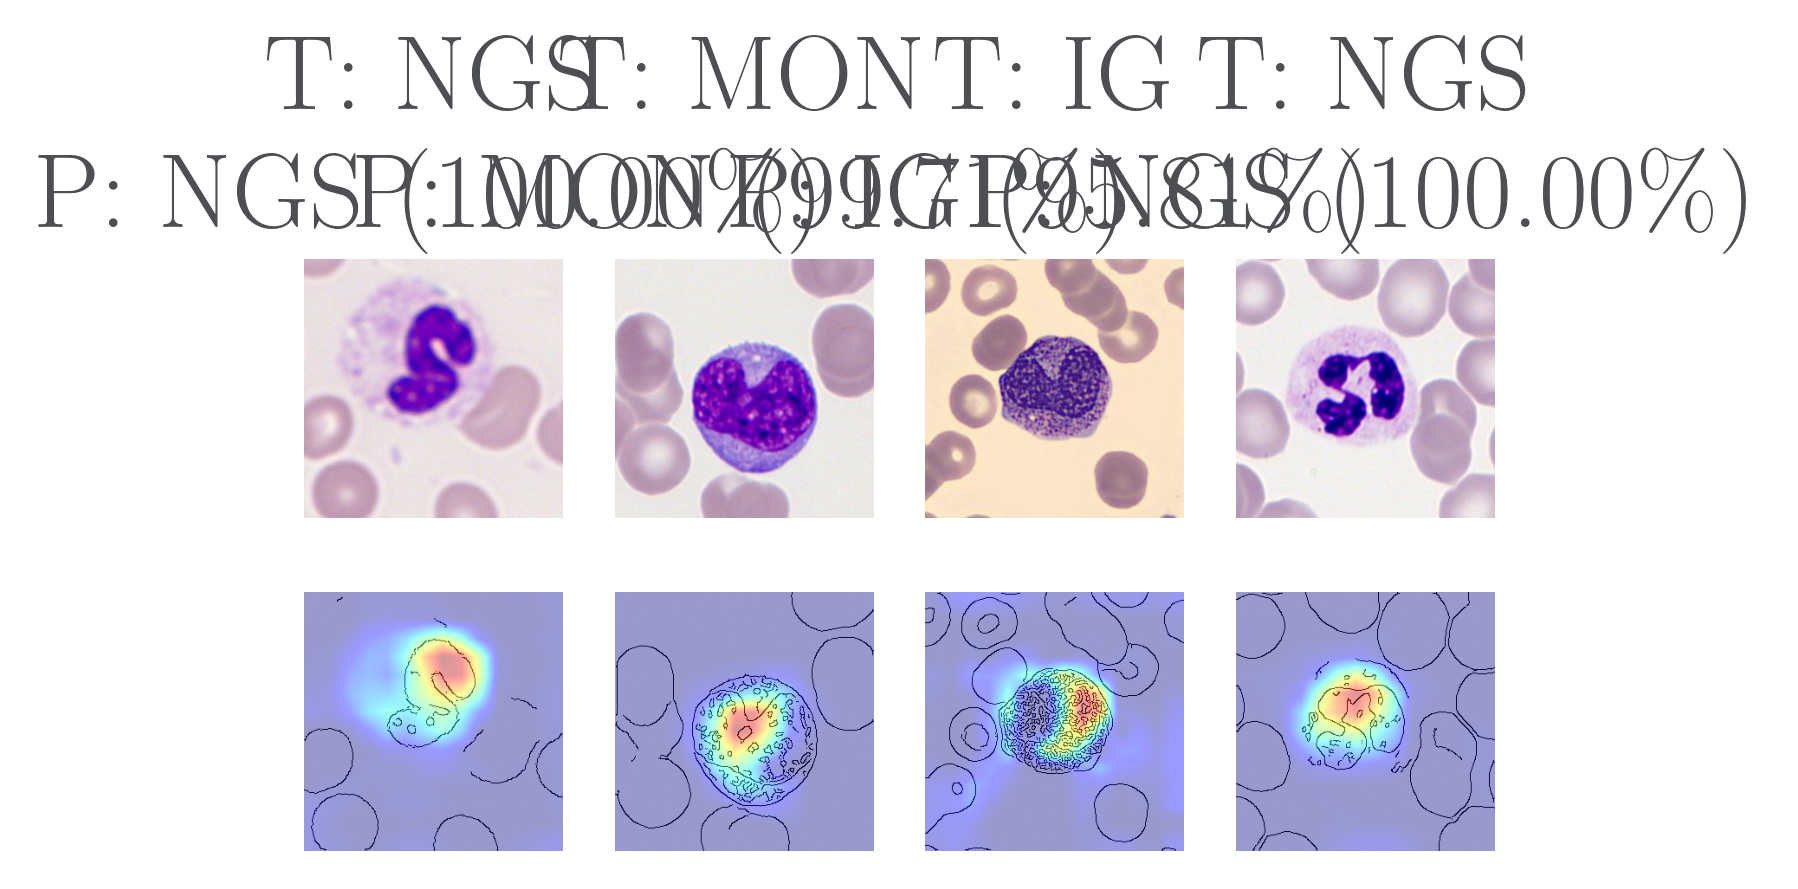

In [ ]:
pplt.use_style()
fig, ax = plt.subplots(2, 4, figsize=(4, 3.3), gridspec_kw={'hspace': -0.4})

n = 1  # number of batches to visualize

for batch_idx, (X_batch, y_batch) in enumerate(test_ds.take(n)):  # TensorFlow dataset
    X_batch = X_batch.numpy()
    y_batch = y_batch.numpy()

    for i in range(4):
        # Original image (rescale to [0,1] for visualization)
        img_disp = X_batch[i]
        img_disp = (img_disp - img_disp.min()) / (img_disp.max() - img_disp.min())
        edge = get_canny_edge(img_disp)

        # Model input (already batched and float32, ensure correct shape)
        img_tensor = np.expand_dims(X_batch[i], axis=0)  # shape (1, H, W, C)
        img_tensor = preprocess_input(img_tensor)

        # Forward pass
        preds = model.predict(img_tensor, verbose=0)
        pred_label = np.argmax(preds[0])
        pred_prob = preds[0][pred_label]

        true_label = y_batch[i]
        pred_class = pred_label

        # Grad-CAM heatmap
        heatmap = make_gradcam_heatmap(img_tensor, model, last_conv_layer_name="block5_conv3")
        heatmap_resized = cv2.resize(heatmap, (edge.shape[1], edge.shape[0]))
        heatmap_color = plt.cm.jet(heatmap_resized)[:, :, :3]

        # Overlay Grad-CAM on edge map
        overlay = 0.4 * heatmap_color + 0.6 * edge
        overlay = np.clip(overlay, 0, 1)

        # Plot original and overlay
        ax[0, i].imshow(img_disp)
        ax[0, i].axis('off')
        ax[0, i].set_title(
            f"T: {class_names[true_label]} \n P: {class_names[pred_class]} ({pred_prob*100:.2f}\%)",
            size=20
        )

        ax[1, i].imshow(overlay)
        ax[1, i].axis('off')

    break  # visualize only the first batch

pplt.savefig('prediction.png', dpi=300)
plt.show()
